# GLES Agreement Review

This notebook loads the saved agreement outputs for the GLES MIP pilot, plots per-variable agreement, shows confusion matrices, and displays disagreement examples inline with the original response text.

The focus here is model-vs-review agreement, not classical human-vs-human inter-coder reliability.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "gles_mip":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from open_codebook.agreement import summarize_review_agreement
from open_codebook.io_utils import load_codebook, load_csv

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_columns", 30)

study_name = "gles_mip_v1"
codebook_path = PROJECT_ROOT / "codebooks" / "gles_mip" / "codebook_v1.yaml"
review_path = PROJECT_ROOT / "outputs" / "gles_mip" / f"{study_name}_review_template.csv"
summary_path = PROJECT_ROOT / "outputs" / "gles_mip" / "agreement_summary.csv"
disagreement_path = PROJECT_ROOT / "outputs" / "gles_mip" / "agreement_disagreements.csv"

codebook = load_codebook(codebook_path)
review_df = load_csv(review_path)
saved_summary_df = pd.read_csv(summary_path)
saved_disagreements_df = pd.read_csv(disagreement_path)
artifacts = summarize_review_agreement(review_df, codebook, id_column="sample_id")

summary_df = saved_summary_df.copy()
disagreements_df = saved_disagreements_df.copy()

print(f"Project root: {PROJECT_ROOT}")
print(f"Review rows: {len(review_df)}")
print(f"Saved summary rows: {len(summary_df)}")
print(f"Saved disagreement rows: {len(disagreements_df)}")

Project root: /Users/jiayunjin/Documents/Research_codes/OpenCodeBook
Review rows: 95
Saved summary rows: 5
Saved disagreement rows: 179


## Agreement Summary

In [3]:
summary_df[["percent_agreement", "kappa"]] = summary_df[["percent_agreement", "kappa"]].round(4)
summary_df.sort_values("kappa", ascending=False).reset_index(drop=True)

,variable,measurement_level,agreement_metric,n_compared,n_matches,percent_agreement,kappa,model_distribution,reviewed_distribution,note
0,multi_issue,nominal,cohen_kappa,95,89,0.9368,0.8649,False=57; True=38,False=63; True=32,NaN
1,issue_domain,nominal,cohen_kappa,95,60,0.6316,0.5678,climate_environment=3; democracy_governance=21; economy=8; foreign_policy_war=5; migration=13; other=15; security=12; social_welfare=16;...,climate_environment=3; democracy_governance=35; economy=13; foreign_policy_war=5; migration=17; security=4; social_welfare=11; unclear=7,NaN
2,framing,nominal,cohen_kappa,95,56,0.5895,0.3456,descriptive=55; directive=4; evaluative=36,descriptive=29; directive=19; evaluative=47,NaN
3,specificity,ordinal,weighted_kappa,95,51,0.5368,0.3101,actor_reference=3; framed_claim=19; label_only=73,actor_reference=10; framed_claim=41; label_only=35; named_policy=9,NaN
4,ambiguity,ordinal,weighted_kappa,95,40,0.4211,0.2657,high=36; low=47; medium=12,high=10; low=36; medium=49,NaN


## Per-Variable Agreement Plot

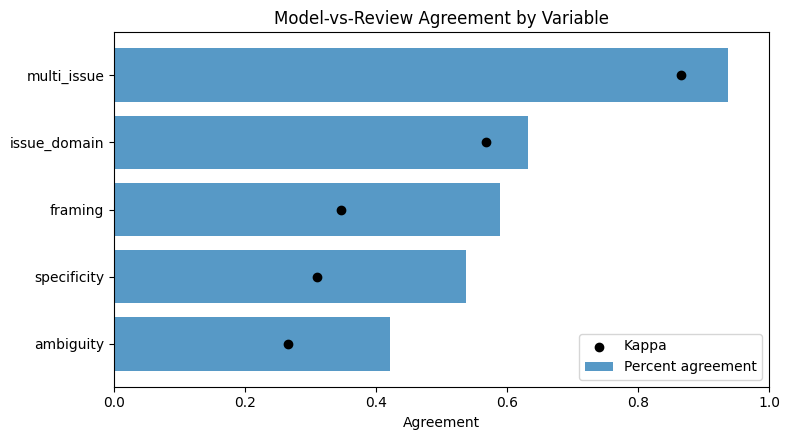

In [4]:
plot_df = summary_df.sort_values("kappa", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(plot_df["variable"], plot_df["percent_agreement"], alpha=0.75, label="Percent agreement")
ax.scatter(plot_df["kappa"], plot_df["variable"], color="black", label="Kappa", zorder=3)
ax.set_xlim(0, 1)
ax.set_xlabel("Agreement")
ax.set_title("Model-vs-Review Agreement by Variable")
ax.legend(loc="lower right")
plt.tight_layout()

## Variables With The Most Friction

In [5]:
summary_df.loc[:, ["variable", "n_compared", "n_matches", "percent_agreement", "kappa"]].sort_values(
    ["percent_agreement", "kappa"],
    ascending=[True, True],
).reset_index(drop=True)

,variable,n_compared,n_matches,percent_agreement,kappa
0,ambiguity,95,40,0.4211,0.2657
1,specificity,95,51,0.5368,0.3101
2,framing,95,56,0.5895,0.3456
3,issue_domain,95,60,0.6316,0.5678
4,multi_issue,95,89,0.9368,0.8649


## Disagreement Counts By Variable

In [6]:
disagreements_df["variable"].value_counts().rename_axis("variable").reset_index(name="n_disagreements")

,variable,n_disagreements
0,ambiguity,55
1,specificity,44
2,framing,39
3,issue_domain,35
4,multi_issue,6


## Disagreement Examples Inline

In [7]:
context_columns = [
    "sample_id",
    "review_group",
    "response_text",
    "issue_domain_model",
    "issue_domain_reviewed",
    "specificity_model",
    "specificity_reviewed",
    "framing_model",
    "framing_reviewed",
    "ambiguity_model",
    "ambiguity_reviewed",
    "multi_issue_model",
    "multi_issue_reviewed",
]

disagreement_examples = disagreements_df.merge(
    review_df[context_columns],
    on=["sample_id", "review_group"],
    how="left",
)

disagreement_examples.head(20)

,sample_id,review_group,variable,model_value,reviewed_value,note,response_text,issue_domain_model,issue_domain_reviewed,specificity_model,specificity_reviewed,framing_model,framing_reviewed,ambiguity_model,ambiguity_reviewed,multi_issue_model,multi_issue_reviewed
0,gles_mip_v1_0115,flagged,issue_domain,security,economy,NaN,Energikosten Sicherheit Frieden und Wirtschaft,security,economy,label_only,label_only,descriptive,descriptive,low,medium,True,True
1,gles_mip_v1_0327,flagged,issue_domain,other,democracy_governance,NaN,Unstimmigkeiten,other,democracy_governance,label_only,label_only,descriptive,evaluative,high,medium,False,False
2,gles_mip_v1_0258,flagged,issue_domain,economy,democracy_governance,NaN,"Aufstieg der Nazipartei AfD, Abschröpfen des Mittelstands und den Armen, Rüstung, Inflation, Fachkräftemangel, Leere Rentenkassen und di...",economy,democracy_governance,framed_claim,actor_reference,evaluative,evaluative,medium,medium,True,True
3,gles_mip_v1_0010,flagged,issue_domain,social_welfare,unclear,NaN,Chronische Unzufriedenheit,social_welfare,unclear,label_only,label_only,evaluative,evaluative,high,high,False,False
4,gles_mip_v1_0223,flagged,issue_domain,other,migration,NaN,"Migration, Klima und Wirtschaft",other,migration,label_only,label_only,descriptive,descriptive,low,medium,True,True
5,gles_mip_v1_0221,flagged,issue_domain,social_welfare,economy,NaN,"Es wird sich meiner Meinung nach zu wenig um die Deutschen gekümmert, Wir brauchen ein festes Einkommen. Wir brauchen alle mehr Geld und...",social_welfare,economy,framed_claim,framed_claim,evaluative,evaluative,low,medium,True,True
6,gles_mip_v1_0243,flagged,issue_domain,security,social_welfare,NaN,Das die falschen Leute inne enger Geld bekommen,security,social_welfare,framed_claim,framed_claim,evaluative,evaluative,high,medium,False,False
7,gles_mip_v1_0062,flagged,issue_domain,other,democracy_governance,NaN,Jeder ist sich selbst der nächste,other,democracy_governance,label_only,framed_claim,descriptive,evaluative,high,medium,False,False
8,gles_mip_v1_0218,flagged,issue_domain,economy,democracy_governance,NaN,Unser Problem ist die gegenwärtige Regierung besonders die Grünen haben unsere Wirtschaft an die Wand gefahren. Weiteres Problem sind di...,economy,democracy_governance,framed_claim,actor_reference,evaluative,directive,low,low,True,True
9,gles_mip_v1_0025,flagged,issue_domain,security,economy,NaN,zuviel Ausgaben ins Ausland (Rüstung und Asylanten),security,economy,framed_claim,framed_claim,evaluative,evaluative,low,medium,True,True


## Focus On One Variable

In [8]:
target_variable = "ambiguity"

disagreement_examples.loc[
    disagreement_examples["variable"] == target_variable,
    ["sample_id", "response_text", "model_value", "reviewed_value", "note"],
].reset_index(drop=True).head(20)

,sample_id,response_text,model_value,reviewed_value,note
0,gles_mip_v1_0115,Energikosten Sicherheit Frieden und Wirtschaft,low,medium,NaN
1,gles_mip_v1_0151,Die Uneinigkeit unter einander,high,medium,NaN
2,gles_mip_v1_0327,Unstimmigkeiten,high,medium,NaN
3,gles_mip_v1_0164,Das die Attentaten aufhören u.die Anschläge auf Veranstaltungen,medium,low,NaN
4,gles_mip_v1_0174,"Flüchtlinge, Steuern, erhöhte Kosten, niedrige Löhne",low,medium,NaN
5,gles_mip_v1_0279,Sanktion für Russland aufzuheben. Inflation zu stoppen,low,medium,NaN
6,gles_mip_v1_0223,"Migration, Klima und Wirtschaft",low,medium,NaN
7,gles_mip_v1_0280,"Wirtschaftslage (Armut und Reichtum), hohe Steuern",low,medium,NaN
8,gles_mip_v1_0221,"Es wird sich meiner Meinung nach zu wenig um die Deutschen gekümmert, Wir brauchen ein festes Einkommen. Wir brauchen alle mehr Geld und...",low,medium,NaN
9,gles_mip_v1_0243,Das die falschen Leute inne enger Geld bekommen,high,medium,NaN


## Confusion Matrices

In [9]:
for target_variable in ["issue_domain", "specificity", "framing", "ambiguity", "multi_issue"]:
    model_column = f"{target_variable}_model"
    reviewed_column = f"{target_variable}_reviewed"
    print(f"\n=== {target_variable} ===")
    display(
        pd.crosstab(
            review_df[model_column],
            review_df[reviewed_column],
            rownames=[f"{target_variable}_model"],
            colnames=[f"{target_variable}_reviewed"],
            dropna=False,
        )
    )


=== issue_domain ===


issue_domain_reviewed,climate_environment,democracy_governance,economy,foreign_policy_war,migration,security,social_welfare,unclear
issue_domain_model,,,,,,,,
climate_environment,3,0,0,0,0,0,0,0
democracy_governance,0,19,0,0,0,0,1,1
economy,0,2,6,0,0,0,0,0
foreign_policy_war,0,0,0,5,0,0,0,0
migration,0,1,0,0,12,0,0,0
other,0,8,3,0,2,0,0,2
security,0,3,2,0,2,4,1,0
social_welfare,0,2,2,0,1,0,9,2
unclear,0,0,0,0,0,0,0,2



=== specificity ===


specificity_reviewed,actor_reference,framed_claim,label_only,named_policy
specificity_model,,,,
actor_reference,3,0,0,0
framed_claim,3,13,0,3
label_only,4,28,35,6



=== framing ===


framing_reviewed,descriptive,directive,evaluative
framing_model,,,
descriptive,28,4,23
directive,0,4,0
evaluative,1,11,24



=== ambiguity ===


ambiguity_reviewed,high,low,medium
ambiguity_model,,,
high,9,8,19
low,0,24,23
medium,1,4,7



=== multi_issue ===


multi_issue_reviewed,False,True
multi_issue_model,,
False,57,0
True,6,32


## Saved CSV Cross-Check

In [10]:
print(summary_path)
print(disagreement_path)
print(f"Saved summary rows: {len(saved_summary_df)}")
print(f"Saved disagreement rows: {len(saved_disagreements_df)}")
print(
    "Summary matches recomputed summary:",
    saved_summary_df[["variable", "n_compared", "n_matches"]].equals(
        artifacts.summary_df[["variable", "n_compared", "n_matches"]]
    ),
)

/Users/jiayunjin/Documents/Research_codes/OpenCodeBook/outputs/gles_mip/agreement_summary.csv
/Users/jiayunjin/Documents/Research_codes/OpenCodeBook/outputs/gles_mip/agreement_disagreements.csv
Saved summary rows: 5
Saved disagreement rows: 179
Summary matches recomputed summary: True
